In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
pd.set_option('display.max_rows', 5000)

train_data = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
train_data.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
test_data = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
# train, test split 
from sklearn.model_selection import train_test_split

# split data into training and validation data, for both features and target
# The split is based on a random number generator. Supplying a numeric value to
# the random_state argument guarantees we get the same split every time we
# run this script.

y = train_data["Survived"]
train_data.head(10)
features = ["Pclass", "Sex","Name", "Age", "SibSp", "Parch", "Fare", "Cabin","Embarked" ]
#X = pd.get_dummies(train_data[features])

train_X, val_X, train_y, val_y = train_test_split(train_data[features], y, random_state = 0)


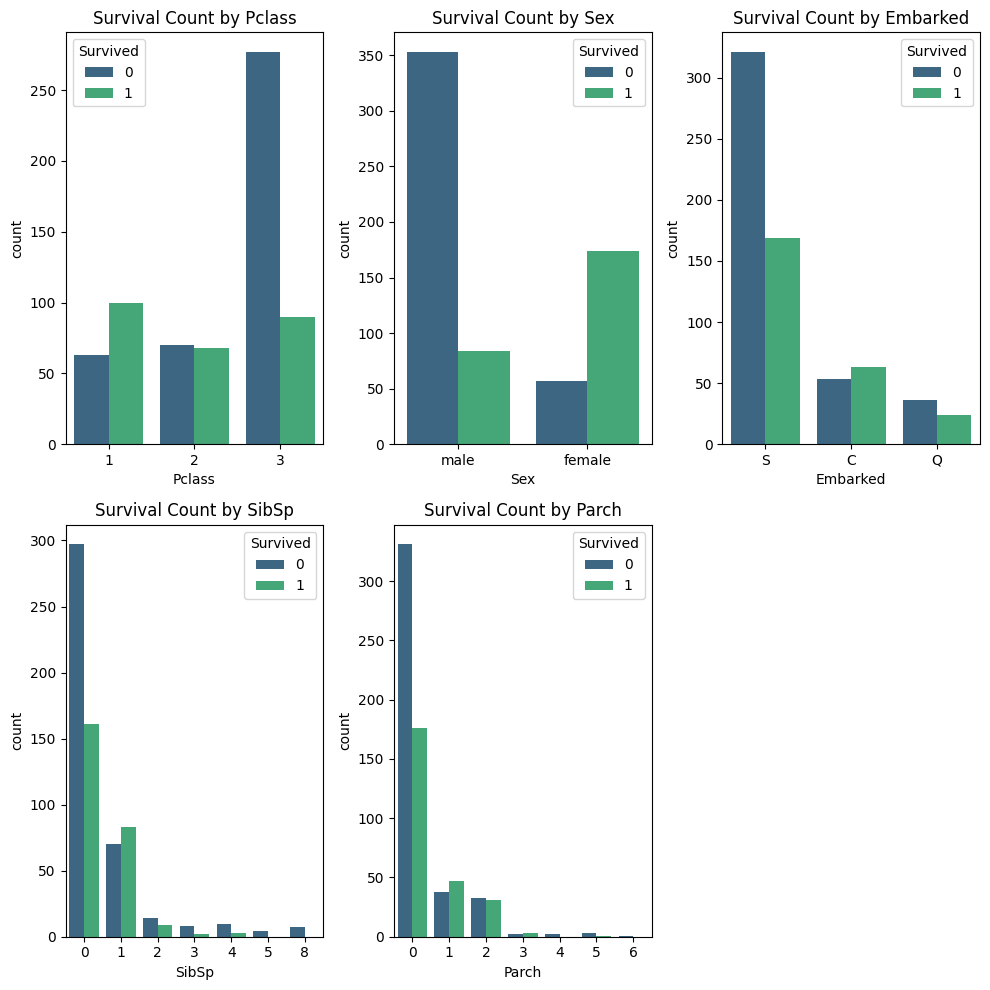

/tmp/ipykernel_16/2740452684.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eda_train_data, x=col, y='Survived', ax=axes[i], palette='magma')
/tmp/ipykernel_16/2740452684.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eda_train_data, x=col, y='Survived', ax=axes[i], palette='magma')
/tmp/ipykernel_16/2740452684.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eda_train_data, x=col, y='Survived', ax=axes[i], palette='magma')
/tmp/ipykernel_16/2740452684.py:40: FutureWarning: 

Passing `palette` without assigning

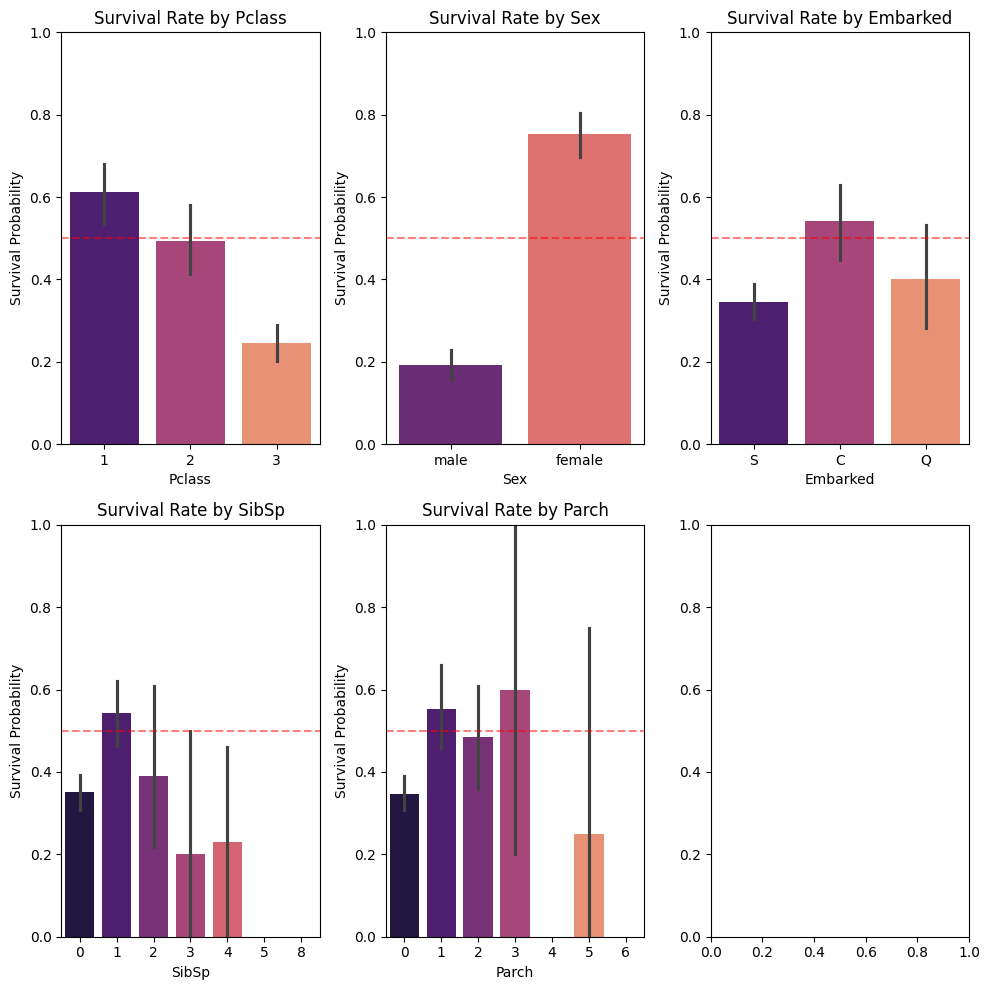

In [5]:
#EDA - Categorical Features 

eda_train_data = pd.concat([train_X, train_y], axis=1).copy()

import seaborn as sns
import matplotlib.pyplot as plt

# List of categorical features
cat_features = ['Pclass', 'Sex', 'Embarked', 'SibSp', 'Parch']

plt.figure(figsize=(10, 10))
for i, col in enumerate(cat_features):
    plt.subplot(2, 3, i+1)
    # This plot shows the count and splits it by Survival
    sns.countplot(data=eda_train_data, x=col, hue='Survived', palette='viridis')
    plt.title(f'Survival Count by {col}')

plt.tight_layout()
plt.show()

# Higher class survive rate low 
# More Female furvived than male 
# S have lower survive rate 
# survive rate is lower if person does not have any sibligs or Parent-child

# chart that compare survive rate instead of just showing count 

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the categorical columns we want to inspect
features = ['Pclass', 'Sex', 'Embarked', 'SibSp', 'Parch']

# 2. Set up the figure and axes
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 10))
axes = axes.flatten() # Flatten the 2D array to easily loop through it

# 3. Loop through features and create barplots
for i, col in enumerate(features):
    sns.barplot(data=eda_train_data, x=col, y='Survived', ax=axes[i], palette='magma')
    
    # Adding a reference line at 50% survival rate
    axes[i].axhline(0.5, ls='--', color='red', alpha=0.5)
    axes[i].set_title(f'Survival Rate by {col}')
    axes[i].set_ylabel('Survival Probability')
    axes[i].set_ylim(0, 1) # Probability is always between 0 and 1

plt.tight_layout()
plt.show()

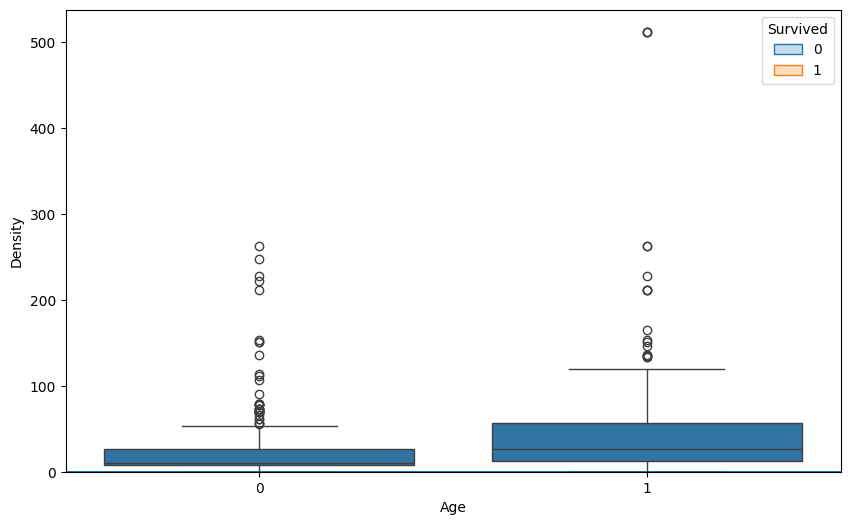

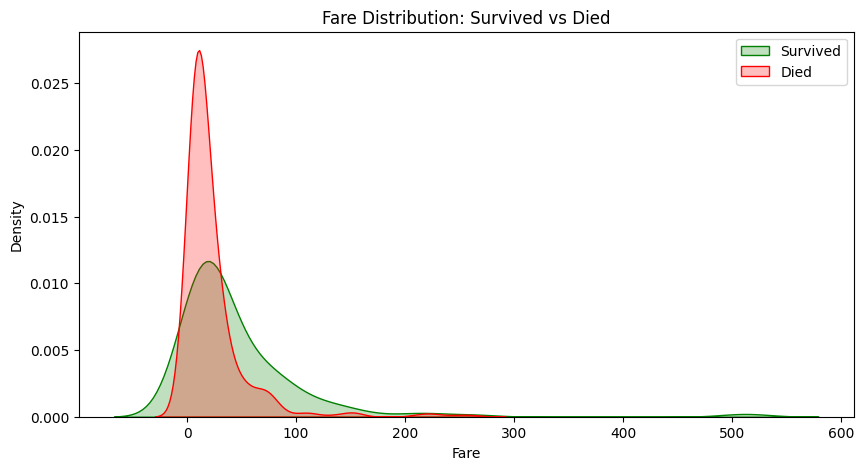

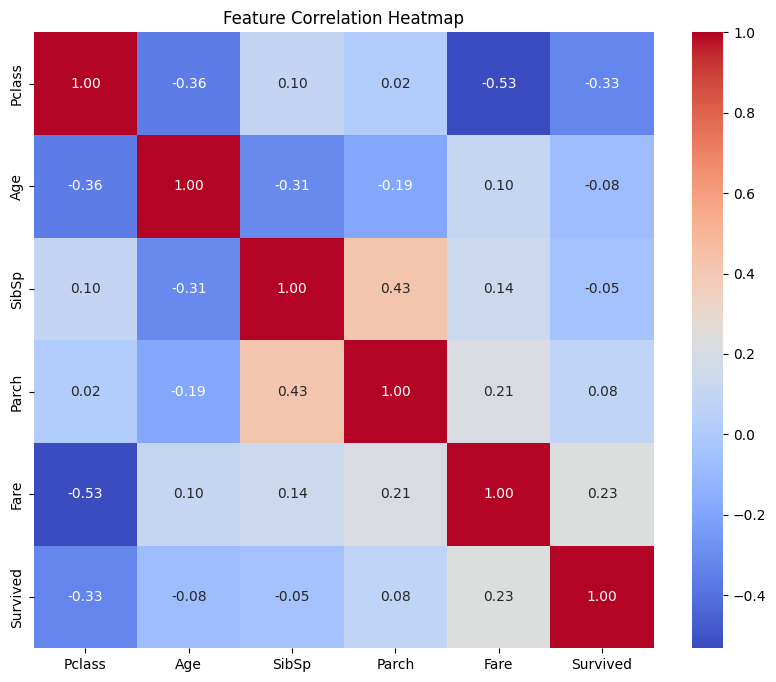

In [6]:
# numerical value EDA 

# Analyzing Age distribution
plt.figure(figsize=(10, 6))
kde_plot = sns.kdeplot(data=eda_train_data, x='Age', hue='Survived', fill=True)


# Look for 'peaks' in survival based on Fare
sns.kdeplot(data=eda_train_data, x='Fare', hue='Survived', fill=True)
plt.xlim(0, 150) # Limit x-axis to see the main cluster clearly

# Did survivors pay more on average?
sns.boxplot(data=eda_train_data, x='Survived', y='Fare')

# Analyzing Fare distribution
plt.figure(figsize=(10, 5))
sns.kdeplot(data=eda_train_data[eda_train_data['Survived'] == 1], x='Fare', fill=True, label='Survived', color='green')
sns.kdeplot(data=eda_train_data[eda_train_data['Survived'] == 0], x='Fare', fill=True, label='Died', color='red')
plt.title('Fare Distribution: Survived vs Died')
plt.legend()
plt.show()
# Select only numerical columns for correlation
numerical_df = eda_train_data.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

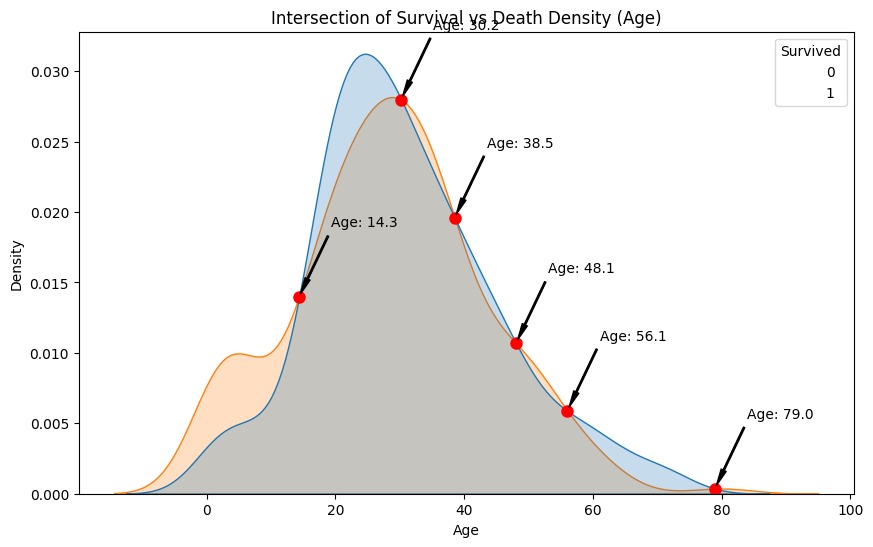

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# 1. Create the plot
plt.figure(figsize=(10, 6))

# IMPORTANT: We use common_norm=False to ensure both curves are scaled 
# independently, which makes the intersection point more meaningful for EDA.
ax = sns.kdeplot(data=eda_train_data, x='Age', hue='Survived', 
                 fill=True, common_norm=False)

# 2. Extract the data points from the underlying PolyCollections
# If get_lines() is empty, we look for the 'collections' instead
if not ax.get_lines():
    # This happens when fill=True. We can force Seaborn to provide lines 
    # by plotting a second time without the fill, or by accessing the paths.
    # Easiest fix: Draw the KDE again WITHOUT fill and alpha=0 (invisible)
    sns.kdeplot(data=eda_train_data, x='Age', hue='Survived', 
                fill=False, common_norm=False, ax=ax, alpha=0)

lines = ax.get_lines()

# 2. Extract the lines from the plot
# line[0] is typically 'Died' (Survived=0), line[1] is 'Survived' (Survived=1)
line0 = lines[0].get_data()
line1 = lines[1].get_data()

# 3. Create interpolation functions for both curves
# This allows us to compare them even if they have different x-coordinates
f0 = interp1d(line0[0], line0[1], bounds_error=False, fill_value=0)
f1 = interp1d(line1[0], line1[1], bounds_error=False, fill_value=0)

# 4. Find the intersection point
# We create a dense range of X values to check
x_range = np.linspace(min(line0[0]), max(line0[0]), 1000)
# Find where the difference is closest to zero
idx = np.argwhere(np.diff(np.sign(f0(x_range) - f1(x_range)))).flatten()

# 5. Mark and label the intersections
for i in idx:
    intersect_x = x_range[i]
    intersect_y = f0(x_range[i])
    
    plt.plot(intersect_x, intersect_y, 'ro', markersize=8) # Red dot
    plt.annotate(f'Age: {intersect_x:.1f}', 
                 xy=(intersect_x, intersect_y), 
                 xytext=(intersect_x + 5, intersect_y + 0.005),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4))

plt.title('Intersection of Survival vs Death Density (Age)')
plt.show()

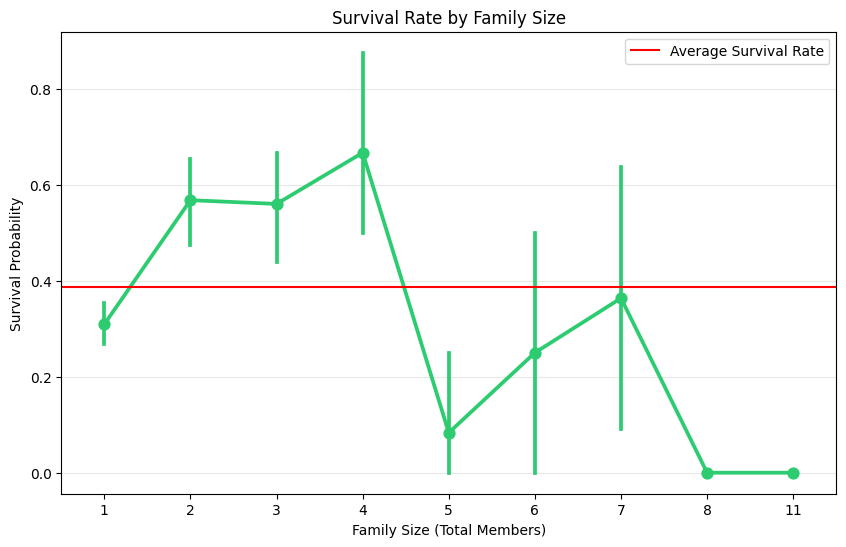

Survival Rate per Family Size:
Family_Size
1     0.309406
2     0.567797
3     0.560000
4     0.666667
5     0.083333
6     0.250000
7     0.363636
8     0.000000
11    0.000000
Name: Survived, dtype: float64


In [8]:
#how to decide family size 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Recombine your split data for plotting
plot_df = pd.concat([train_X, train_y], axis=1)

# 2. Create the Family_Size feature (SibSp + Parch + the passenger themselves)
plot_df['Family_Size'] = plot_df['SibSp'] + plot_df['Parch'] + 1

# 3. Create the visualization
plt.figure(figsize=(10, 6))

# We use a pointplot to see the trend and the confidence intervals (error lines)
sns.pointplot(data=plot_df, x='Family_Size', y='Survived', color='#2ecc71')

# Add a horizontal line for the overall average survival rate for context
plt.axhline(plot_df['Survived'].mean(), color='red', label='Average Survival Rate')

plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size (Total Members)')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. Show the raw numbers to verify the "Sweet Spot"
print("Survival Rate per Family Size:")
print(plot_df.groupby('Family_Size')['Survived'].mean())

/tmp/ipykernel_16/1998473814.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eda_train_data, x=col, y='Survived', ax=axes[i], palette='magma')
/tmp/ipykernel_16/1998473814.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eda_train_data, x=col, y='Survived', ax=axes[i], palette='magma')
/tmp/ipykernel_16/1998473814.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eda_train_data, x=col, y='Survived', ax=axes[i], palette='magma')
/tmp/ipykernel_16/1998473814.py:46: FutureWarning: 

Passing `palette` without assigning

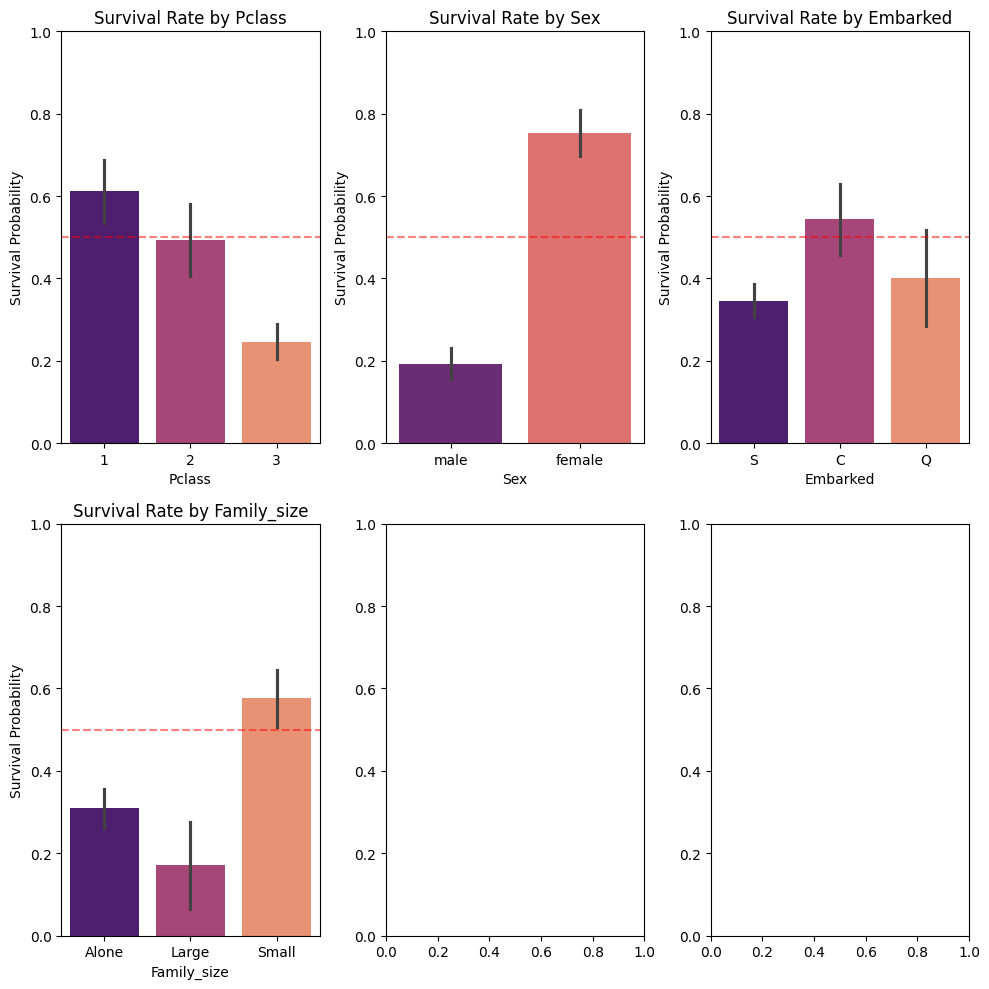

In [9]:
# feature engineering for sibsp + parch 
eda_train_data['Family_size'] = eda_train_data['SibSp'] + eda_train_data['Parch'] + 1

eda_train_data.head(50)

def categorize_family_size(df):
    if df == 1:
        return 'Alone'
    elif 2 <= df <= 4:
        return 'Small'
    else : 
        return 'Large'


def categorize_Age(df):
    if df <= 14.3:
        return 'Child'
    elif 14.3 < df <= 56.1:
        return 'Adult'
    else : 
        return 'Elder'

eda_train_data['Family_size'] = eda_train_data['Family_size'].apply(categorize_family_size)

#eda_train_data.loc[eda_train_data['Family_size']=='Large',:]

# Higher class survive rate low 
# More Female furvived than male 
# S have lower survive rate 
# survive rate is lower if person does not have any sibligs or Parent-child

# chart that compare survive rate instead of just showing count 

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the categorical columns we want to inspect
features = ['Pclass', 'Sex', 'Embarked','Family_size']

# 2. Set up the figure and axes
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 10))
axes = axes.flatten() # Flatten the 2D array to easily loop through it

# 3. Loop through features and create barplots
for i, col in enumerate(features):
    sns.barplot(data=eda_train_data, x=col, y='Survived', ax=axes[i], palette='magma')
    
    # Adding a reference line at 50% survival rate
    axes[i].axhline(0.5, ls='--', color='red', alpha=0.5)
    axes[i].set_title(f'Survival Rate by {col}')
    axes[i].set_ylabel('Survival Probability')
    axes[i].set_ylim(0, 1) # Probability is always between 0 and 1

plt.tight_layout()
plt.show()

In [10]:
#applying feature engineering in train and valid 

train_X_family_size = train_X.copy()
valid_X_family_size = val_X.copy()
test_X_family_size = test_data.copy()

train_X_family_size['Family_size'] = train_X_family_size['SibSp'] + train_X_family_size['Parch'] + 1
train_X_family_size['Family_size'] = train_X_family_size['Family_size'].apply(categorize_family_size)

#train_X_family_size['Age'] = train_X_family_size['Age'].apply(categorize_Age)

valid_X_family_size['Family_size'] = valid_X_family_size['SibSp'] + valid_X_family_size['Parch'] + 1
valid_X_family_size['Family_size'] = valid_X_family_size['Family_size'].apply(categorize_family_size)
#valid_X_family_size['Age'] = valid_X_family_size['Age'].apply(categorize_Age)

test_X_family_size['Family_size'] = test_X_family_size['SibSp'] + test_X_family_size['Parch'] + 1
test_X_family_size['Family_size'] = test_X_family_size['Family_size'].apply(categorize_family_size)


test_X_family_size.head(50)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_size
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Alone
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Small
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Alone
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Alone
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Small
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S,Alone
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q,Alone
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S,Small
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C,Alone
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S,Small


In [11]:
#handling missing values 

#1 understand how much data get NaN. 
#1-1
age_missing_portion = train_X.loc[train_X.loc[:, 'Age'].isnull(),:].shape[0] / train_X.shape[0] * 100
print("%  of Age column is missing : ", round(age_missing_portion, 2)) # 19.87%

#1-2
cabin_missing_portion = train_data['Cabin'].isnull().mean() * 100
print("%  of Cabin column is missing : ", round(cabin_missing_portion, 2)) # 19.87%

#1-3
Embarked_missing_portion = train_X['Embarked'].isnull().mean() * 100
print("%  of Embarked column is missing : ", round(Embarked_missing_portion, 2)) # 19.87%

#2 get suffix of each one and get mean age of each group and apply it to missing value 
train_data_with_suffix = train_X_family_size.copy()
valid_data_with_suffix = valid_X_family_size.copy()
test_data_with_suffix = test_X_family_size.copy()

def extract_suffix(df):
    df['Suffix'] = df['Name'].str.split(',',expand=True).iloc[:,1].str.split('.', expand = True).iloc[:,0].str.strip()
    return df 
    
train_data_with_suffix = extract_suffix(train_data_with_suffix)
valid_data_with_suffix = extract_suffix(valid_data_with_suffix)
test_data_with_suffix = extract_suffix(test_data_with_suffix)

means_from_train = train_data_with_suffix.groupby('Suffix')['Age'].mean()

train_data_with_suffix['Age'] = train_data_with_suffix['Age'].fillna(train_data_with_suffix['Suffix'].map(means_from_train))
valid_data_with_suffix['Age'] = valid_data_with_suffix['Age'].fillna(valid_data_with_suffix['Suffix'].map(means_from_train))
test_data_with_suffix['Age'] = test_data_with_suffix['Age'].fillna(test_data_with_suffix['Suffix'].map(means_from_train))


#3 create new column that shows whether person have cabin or not 
train_data_with_suffix['IsCabin'] = train_data_with_suffix['Cabin'].notna().astype('int')
valid_data_with_suffix['IsCabin'] = valid_data_with_suffix['Cabin'].notna().astype('int')
test_data_with_suffix['IsCabin'] = test_data_with_suffix['Cabin'].notna().astype('int')

#4 use mode value to fillout missing values in Embarked column 
Embarked_mode_value = train_data_with_suffix['Embarked'].mode()[0]

train_data_with_suffix['Embarked'].fillna(Embarked_mode_value)
valid_data_with_suffix['Embarked'].fillna(Embarked_mode_value)
test_data_with_suffix['Embarked'].fillna(Embarked_mode_value)


train_data_with_suffix['Age'] = train_data_with_suffix['Age'].apply(categorize_Age)
valid_data_with_suffix['Age'] = valid_data_with_suffix['Age'].apply(categorize_Age)
test_data_with_suffix['Age'] = test_data_with_suffix['Age'].apply(categorize_Age)

test_data_with_suffix.head(50)

%  of Age column is missing :  19.91
%  of Cabin column is missing :  77.1
%  of Embarked column is missing :  0.3


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_size,Suffix,IsCabin
0,892,3,"Kelly, Mr. James",male,Adult,0,0,330911,7.8292,NaN,Q,Alone,Mr,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,Adult,1,0,363272,7.0000,NaN,S,Small,Mrs,0
2,894,2,"Myles, Mr. Thomas Francis",male,Elder,0,0,240276,9.6875,NaN,Q,Alone,Mr,0
3,895,3,"Wirz, Mr. Albert",male,Adult,0,0,315154,8.6625,NaN,S,Alone,Mr,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,Adult,1,1,3101298,12.2875,NaN,S,Small,Mrs,0
5,897,3,"Svensson, Mr. Johan Cervin",male,Child,0,0,7538,9.2250,NaN,S,Alone,Mr,0
6,898,3,"Connolly, Miss. Kate",female,Adult,0,0,330972,7.6292,NaN,Q,Alone,Miss,0
7,899,2,"Caldwell, Mr. Albert Francis",male,Adult,1,1,248738,29.0000,NaN,S,Small,Mr,0
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,Adult,0,0,2657,7.2292,NaN,C,Alone,Mrs,0
9,901,3,"Davies, Mr. John Samuel",male,Adult,2,0,A/4 48871,24.1500,NaN,S,Small,Mr,0


In [12]:
#change category value into numerical 

#1 change ordinal value into numerical usign Labelencoder 
from sklearn.preprocessing import LabelEncoder
# The pandas way is very quick for EDA
from sklearn.preprocessing import OneHotEncoder

train_data_dummies = train_data_with_suffix.loc[:,['Pclass','IsCabin','Sex','Age','Embarked','Family_size']].copy()
valid_data_dummies = valid_data_with_suffix.loc[:,['Pclass','IsCabin','Sex','Age','Embarked','Family_size']].copy()
test_data_dummies = test_data_with_suffix.loc[:,['Pclass','IsCabin','Sex','Age','Embarked','Family_size']].copy()

# 1. Initialize the encoder
# handle_unknown='ignore' ensures that if a new category appears in valid, it won't crash
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 2. FIT and TRANSFORM the training data
# This is where the encoder "learns" that Alone, Small, and Large exist
train_data_dummies = ohe.fit_transform(train_data_dummies[['Sex', 'Age', 'Embarked', 'Family_size']])

# 3. TRANSFORM the validation data (NO FITTING!)
# This uses the "memory" of the training categories to encode the validation data
valid_data_dummies = ohe.transform(valid_data_dummies[['Sex', 'Age', 'Embarked', 'Family_size']])
test_data_dummies = ohe.transform(test_data_dummies[['Sex', 'Age', 'Embarked', 'Family_size']])

# Convert back to DataFrames to keep things clean
train_encoded_df = pd.DataFrame(train_data_dummies, columns=ohe.get_feature_names_out(), index=train_data_with_suffix.index)
valid_encoded_df = pd.DataFrame(valid_data_dummies, columns=ohe.get_feature_names_out(), index=valid_data_with_suffix.index)
test_encoded_df = pd.DataFrame(test_data_dummies, columns=ohe.get_feature_names_out(), index=test_data_with_suffix.index)


train_final = pd.concat([train_data_with_suffix.loc[:,['Pclass','IsCabin']], train_encoded_df], axis = 1)
valid_final = pd.concat([valid_data_with_suffix.loc[:,['Pclass','IsCabin']], valid_encoded_df], axis = 1)
test_final = pd.concat([test_data_with_suffix.loc[:,['Pclass','IsCabin']], test_encoded_df], axis = 1)

test_final.head(40)

,Pclass,IsCabin,Sex_female,Sex_male,Age_Adult,Age_Child,Age_Elder,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan,Family_size_Alone,Family_size_Large,Family_size_Small
0,3,0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,3,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,2,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,3,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,3,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5,3,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
6,3,0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7,2,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
8,3,0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
9,3,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [13]:
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
# max_leaf_nodes = 5
# model = DecisionTreeClassifier(max_leaf_nodes=max_leaf_nodes, random_state=0)
# model.fit(train_X, train_y)

# preds_val = model.predict(val_X)
# print(preds_val)


def get_accuracy(max_leaf_nodes, train_X, val_X, train_y, val_y):
    model = DecisionTreeClassifier(max_leaf_nodes=max_leaf_nodes, random_state=0)
    model.fit(train_X, train_y)
    preds_val = model.predict(val_X)
    acc = accuracy_score(val_y, preds_val)
    return acc

# compare accuracy with different tree sizes
#for max_leaf_nodes in [5, 50, 500, 5000]:
#    my_acc = get_accuracy(max_leaf_nodes, train_X, val_X, train_y, val_y)
#    print(max_leaf_nodes, my_acc)

In [14]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=1, min_samples_leaf = 5)
model.fit(train_final, train_y)

RandomForestClassifier(max_depth=5, min_samples_leaf=5, n_estimators=150,
                       random_state=1)

In [15]:
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance

# 1. 원본 카테고리별로 묶어줄 딕셔너리 짜기
# One-Hot Encoding으로 인해 늘어난 컬럼들을 원래 한 가족이었던 이름으로 묶어줍니다.
feature_groups = {
    'Sex': ['Sex_female', 'Sex_male'],
    'Age': ['Age_Child','Age_Adult', 'Age_Elder'],
    'Pclass': ['Pclass'], # 쪼개지지 않은 수치형 변수는 그냥 그대로 유지
    'IsCabin' : ['IsCabin'],
    'Embarked' : ['Embarked_C','Embarked_Q','Embarked_S','Embarked_nan'],
    'Family_size' : ['Family_size_Alone','Family_size_Large','Family_size_Small']
}
#valid_final.head(5)
group_results = {}
# 기존 2번 루프 영역을 이 코드로 대체해줘!
for group_name, columns in feature_groups.items():
    X_val_shuffled = valid_final.copy()
    
    # [수정] 인덱스 번호가 아니라, 0부터 데이터 개수만큼의 '순서(위치)'를 뒤섞음
    shuffled_positions = np.random.permutation(len(X_val_shuffled))
    
    # [수정] .iloc에 순서(positions)를 넣어주면 인덱스가 균일하지 않아도 안전하게 섞임!
    X_val_shuffled[columns] = X_val_shuffled[columns].iloc[shuffled_positions].values
    
    # 베이스라인 점수와 비교
    baseline_score = model.score(valid_final, val_y)
    shuffled_score = model.score(X_val_shuffled, val_y)
    
    group_results[group_name] = baseline_score - shuffled_score

# 3. 결과 출력
importances_df = pd.DataFrame({
    'Feature_Group': group_results.keys(),
    'Importance_Drop': group_results.values()
}).sort_values(by='Importance_Drop', ascending=False)

print("--- [그룹화] 순열 중요도 결과 ---")
print(importances_df.to_string(index=False))

--- [그룹화] 순열 중요도 결과 ---
Feature_Group  Importance_Drop
          Sex         0.210762
  Family_size         0.058296
          Age         0.026906
       Pclass         0.004484
      IsCabin         0.000000
     Embarked         0.000000


In [16]:
#CV validation 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
# This will test 2 (n_estimators) x 4 (max_depth) x 3 (min_samples_leaf) = 24 combinations
param_grid = {
    'n_estimators': [100,150, 200],
    'max_depth': [5, 6, 7, 8, 9, 10],
    'min_samples_leaf': [3, 4, 5, 6]
}

# 2. Initialize the Grid Search
# cv=5 means 5-fold cross-validation (highly recommended for stable scores)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    return_train_score=True, # Allows us to check for overfitting
    n_jobs=-1               # Uses all available CPU cores to speed it up
)

# 3. Run the grid search on your training data
grid_search.fit(train_final, train_y)

# 4. Convert the results into a readable Pandas DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Filter down to the most important columns for comparison
columns_to_keep = [
    'param_max_depth', 
    'param_min_samples_leaf', 
    'param_n_estimators', 
    'mean_test_score',  # This is the average validation score
    'mean_train_score'  # This is the training score
]
comparison_table = results_df[columns_to_keep].sort_values(by='mean_test_score', ascending=False)

# Print the top 5 parameter sets
print("--- TOP 5 PARAMETER COMBINATIONS ---")
print(comparison_table.head(5).to_string(index=False))

print(f"\nBest Parameters Found: {grid_search.best_params_}")
print(f"Best Validation Accuracy: {grid_search.best_score_:.4f}")

--- TOP 5 PARAMETER COMBINATIONS ---
 param_max_depth  param_min_samples_leaf  param_n_estimators  mean_test_score  mean_train_score
               5                       5                 150         0.833879          0.839447
               5                       5                 200         0.832376          0.839821
               5                       4                 200         0.832364          0.840193
               5                       6                 200         0.830894          0.836081
               5                       6                 100         0.830883          0.835708

Best Parameters Found: {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 150}
Best Validation Accuracy: 0.8339


In [17]:
#do validation 
from sklearn.metrics import mean_absolute_error
# get predicted prices on validation data
val_predictions = model.predict(valid_final)
print(mean_absolute_error(val_y, val_predictions))
# max_depth = 5 : 0.17488789237668162 , 6: 0.17040358744394618, 7 : 0.18385650224215247, 8: 0.16591928251121077, 9: 0.16591928251121077,

0.17488789237668162


In [18]:
# make prediction 

predictions = model.predict(test_final)

In [19]:
#generate output 

output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
